<a href="https://colab.research.google.com/github/joshuahberry/tad-2026/blob/main/10_rlhf_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 10: RLHF — Reinforcement Learning from Human Feedback

## Text as Data

Professor: Elliott Ash, NYU

TA: Eduardo Zago, NYU

We have now trained GPT-2 from scratch, fine-tuned it for classification, and fine-tuned it to follow instructions. Today we cover the third and final training paradigm: **RLHF** — the technique behind ChatGPT, Claude, and every modern assistant LLM.

Objectives:

1) Reinforcement learning intuition — the bandit problem
2) The RLHF pipeline: SFT → Reward Model → PPO
3) LoRA: fine-tuning with almost no compute
4) A working RLHF demo (GPT-2 + sentiment reward)

Code adapted from: Raschka Ch. 7 appendix, HuggingFace TRL library, InstructGPT paper (Ouyang et al. 2022)

---
## Part 1 — Reinforcement Learning Intuition

### What is reinforcement learning?

All the training we have done so far was **supervised**: we had labelled data (next token, spam/not spam, instruction–response pairs) and minimised a loss that compared predictions to labels.

**Reinforcement learning (RL)** is different. There are no labels. Instead:

- An **agent** (the model) takes **actions** (generates tokens)
- The environment returns a **reward** signal after the fact
- The agent's goal is to learn a **policy** — a mapping from situations to actions — that **maximises cumulative reward**

This is how humans learn many things: not from a teacher correcting every move, but from trial, error, and delayed feedback.

### The vocabulary, mapped to LLMs

| RL concept | LLM equivalent |
|---|---|
| Agent | The language model |
| State | The current context window (tokens so far) |
| Action | The next token sampled from the distribution |
| Policy | The model's weights (determines token probabilities) |
| Reward | A score assigned to the full generated response |
| Episode | One full generation (prompt → response) |

The key difference from supervised learning: **the reward comes at the end of the whole response**, not token-by-token. The model has to figure out which of its many token choices were responsible for a good or bad outcome — this is the **credit assignment problem**.

### The simplest RL setting: the Multi-Armed Bandit

Before diving into LLMs, let's build intuition with the simplest possible RL problem. Imagine you walk into a casino with three slot machines ("arms"). Each pays out a reward drawn from an unknown distribution. You want to maximise your total winnings over 500 pulls.

The core tension: **explore** (try different arms to learn their distributions) vs **exploit** (pull the arm you currently think is best).

This is exactly the tension in RLHF: the LLM must explore different phrasings to learn what humans reward, while not drifting too far from what it already knows.

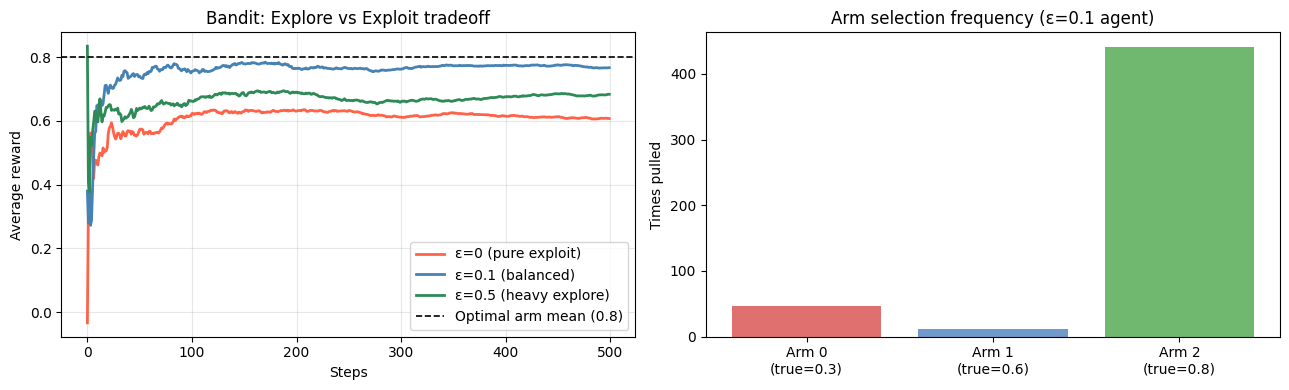

Key insight: pure exploitation (ε=0) gets stuck on a suboptimal arm.
Heavy exploration (ε=0.5) wastes pulls. Balance is crucial.
The same tradeoff exists in RLHF: the LLM must explore response styles
without wandering so far that it forgets how to speak English.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

np.random.seed(42)

# ── Define 3 slot machines with unknown reward distributions ─────────────────
# Each arm has a true mean reward the agent does NOT know
true_means = [0.3, 0.6, 0.8]   # Arm 2 is best, but agent doesn't know this
n_arms     = len(true_means)

def pull_arm(arm_idx):
    """Simulate pulling an arm — returns a noisy reward."""
    return np.random.normal(true_means[arm_idx], scale=0.3)

# ── Epsilon-greedy agent ──────────────────────────────────────────────────────
# With probability epsilon → explore (random arm)
# With probability 1-epsilon → exploit (best arm seen so far)
def run_bandit(epsilon, n_steps=500):
    counts   = np.zeros(n_arms)       # How many times each arm pulled
    estimates = np.zeros(n_arms)      # Running reward estimate per arm
    rewards  = []
    choices  = []

    for t in range(n_steps):
        if np.random.rand() < epsilon:
            action = np.random.randint(n_arms)   # Explore
        else:
            action = np.argmax(estimates)         # Exploit: pick whichever arm currently has the highest estimated mean

        reward = pull_arm(action)
        counts[action]   += 1
        # Incremental mean update: new_mean = old_mean + (reward - old_mean) / n
        estimates[action] += (reward - estimates[action]) / counts[action]
        rewards.append(reward)
        choices.append(action)

    return np.array(rewards), np.array(choices), estimates

# ── Run three agents with different exploration rates ────────────────────────
epsilons = [0.0, 0.1, 0.5]
labels   = ["ε=0 (pure exploit)", "ε=0.1 (balanced)", "ε=0.5 (heavy explore)"]
colors   = ["tomato", "steelblue", "seagreen"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for eps, label, color in zip(epsilons, labels, colors):
    rewards, choices, estimates = run_bandit(eps)
    # Smoothed cumulative average reward
    cumavg = np.cumsum(rewards) / (np.arange(len(rewards)) + 1)
    axes[0].plot(cumavg, label=label, color=color, linewidth=2)

axes[0].axhline(true_means[2], color="black", linestyle="--", linewidth=1.2,
                label=f"Optimal arm mean ({true_means[2]})")
axes[0].set_xlabel("Steps"); axes[0].set_ylabel("Average reward")
axes[0].set_title("Bandit: Explore vs Exploit tradeoff")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Show arm selection frequency for the balanced agent
_, choices_balanced, _ = run_bandit(0.1)
axes[1].bar(["Arm 0\n(true=0.3)", "Arm 1\n(true=0.6)", "Arm 2\n(true=0.8)"],
            [(choices_balanced==i).sum() for i in range(n_arms)],
            color=["#e07070","#7099cc","#70b870"])
axes[1].set_title("Arm selection frequency (ε=0.1 agent)")
axes[1].set_ylabel("Times pulled")

plt.tight_layout(); plt.show()

print("Key insight: pure exploitation (ε=0) gets stuck on a suboptimal arm.")
print("Heavy exploration (ε=0.5) wastes pulls. Balance is crucial.")
print("The same tradeoff exists in RLHF: the LLM must explore response styles")
print("without wandering so far that it forgets how to speak English.")

### From bandits to RLHF

The bandit problem has **no state** — every pull is independent. An LLM generating text has state: each token depends on all previous tokens. This makes it a **Markov Decision Process (MDP)**.

But the core intuition is the same:

1. The model generates a response (takes a sequence of actions)
2. A reward signal arrives (human preference score, or a model trained to predict it)
3. The policy (model weights) is updated to make high-reward actions more likely

The algorithm used to do this update in InstructGPT and ChatGPT is **Proximal Policy Optimization (PPO)** — essentially a careful gradient step that improves the policy without changing it so drastically that it becomes unstable.

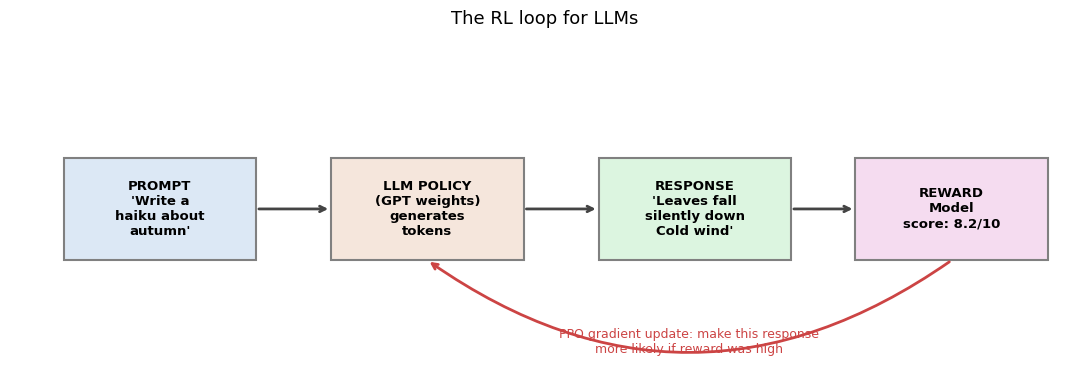

In [ ]:
# ── Visualise the RL loop for LLMs ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
ax.axis("off")

boxes = [
    (0.05, 0.35, 0.18, 0.30, "PROMPT\n'Write a\nhaiku about\nautumn'",   "#dce8f5"),
    (0.30, 0.35, 0.18, 0.30, "LLM POLICY\n(GPT weights)\ngenerates\ntokens",    "#f5e6dc"),
    (0.55, 0.35, 0.18, 0.30, "RESPONSE\n'Leaves fall\nsilently down\nCold wind'", "#dcf5e0"),
    (0.79, 0.35, 0.18, 0.30, "REWARD\nModel\nscore: 8.2/10",                      "#f5dcf0"),
]
arrows = [(0.23, 0.50, 0.07), (0.48, 0.50, 0.07), (0.73, 0.50, 0.06)]

for x, y, w, h, txt, color in boxes:
    ax.add_patch(plt.Rectangle((x, y), w, h, color=color,
                                ec="gray", lw=1.5, transform=ax.transAxes))
    ax.text(x + w/2, y + h/2, txt, ha="center", va="center",
            fontsize=9.5, transform=ax.transAxes, fontweight="bold")

for x, _, dx in arrows:
    ax.annotate("", xy=(x+dx, 0.50), xytext=(x, 0.50),
                xycoords="axes fraction",
                arrowprops=dict(arrowstyle="->", lw=2, color="#444"))

# Feedback arrow back to policy
ax.annotate("", xy=(0.39, 0.35), xytext=(0.88, 0.35),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="->", lw=2, color="#c44",
                            connectionstyle="arc3,rad=-0.35"))
ax.text(0.635, 0.08, "PPO gradient update: make this response\nmore likely if reward was high",
        ha="center", fontsize=9, color="#c44", transform=ax.transAxes)

ax.set_title("The RL loop for LLMs", fontsize=13, pad=10)
plt.tight_layout(); plt.show()

---
## Part 2 — The RLHF Pipeline

InstructGPT (the paper behind ChatGPT) introduced a three-stage training pipeline. Each stage builds on the previous one.

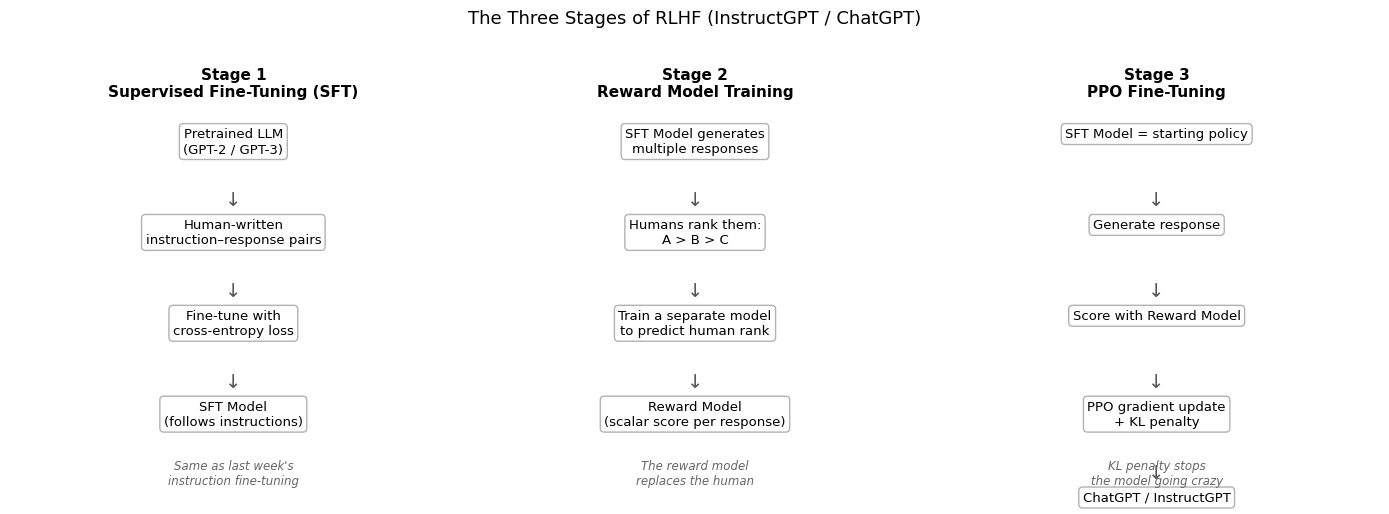

In [ ]:
# ── Draw the three-stage RLHF pipeline ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("The Three Stages of RLHF (InstructGPT / ChatGPT)", fontsize=13, y=1.02)

stages = [
    {
        "title": "Stage 1\nSupervised Fine-Tuning (SFT)",
        "color": "#d4e8f7",
        "steps": [
            "Pretrained LLM\n(GPT-2 / GPT-3)",
            "\u2193",
            "Human-written\ninstruction\u2013response pairs",
            "\u2193",
            "Fine-tune with\ncross-entropy loss",
            "\u2193",
            "SFT Model\n(follows instructions)"
        ],
        "note": "Same as last week's\ninstruction fine-tuning"
    },
    {
        "title": "Stage 2\nReward Model Training",
        "color": "#f7ead4",
        "steps": [
            "SFT Model generates\nmultiple responses",
            "\u2193",
            "Humans rank them:\nA > B > C",
            "\u2193",
            "Train a separate model\nto predict human rank",
            "\u2193",
            "Reward Model\n(scalar score per response)"
        ],
        "note": "The reward model\nreplaces the human"
    },
    {
        "title": "Stage 3\nPPO Fine-Tuning",
        "color": "#d4f7d8",
        "steps": [
            "SFT Model = starting policy",
            "\u2193",
            "Generate response",
            "\u2193",
            "Score with Reward Model",
            "\u2193",
            "PPO gradient update\n+ KL penalty",
            "\u2193",
            "ChatGPT / InstructGPT"
        ],
        "note": "KL penalty stops\nthe model going crazy"
    }
]

for ax, stage in zip(axes, stages):
    ax.set_facecolor(stage["color"])
    ax.set_title(stage["title"], fontsize=11, fontweight="bold", pad=8)
    ax.axis("off")
    y = 0.95
    for step in stage["steps"]:
        if step == "\u2193":
            ax.text(0.5, y, step, ha="center", va="top", fontsize=14,
                    color="#555", transform=ax.transAxes)
            y -= 0.07
        else:
            ax.text(0.5, y, step, ha="center", va="top", fontsize=9.5,
                    transform=ax.transAxes,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor="#aaa", alpha=0.9))
            y -= 0.16
    ax.text(0.5, 0.04, stage["note"], ha="center", va="bottom",
            fontsize=8.5, color="#666", style="italic", transform=ax.transAxes)

plt.tight_layout(); plt.show()

### The KL penalty — why it matters

In Stage 3, the PPO update includes a **KL divergence penalty**:

$$\mathcal{L}_{\text{PPO}} = \mathbb{E}\left[r_\theta(x, y)\right] - \beta \cdot D_{\text{KL}}\left[\pi_\theta(y|x) \| \pi_{\text{SFT}}(y|x)\right]$$

- $r_\theta$ = reward model score
- $D_{\text{KL}}$ = how far the current policy has drifted from the SFT model
- $\beta$ = penalty strength (typically 0.01–0.1)

**Why?** Without this penalty, the model would quickly learn to game the reward model — producing text that scores high but is nonsensical. The KL term acts like a leash, keeping the model close to sensible language while still improving on the reward signal.

This is the RL equivalent of regularisation in supervised learning.

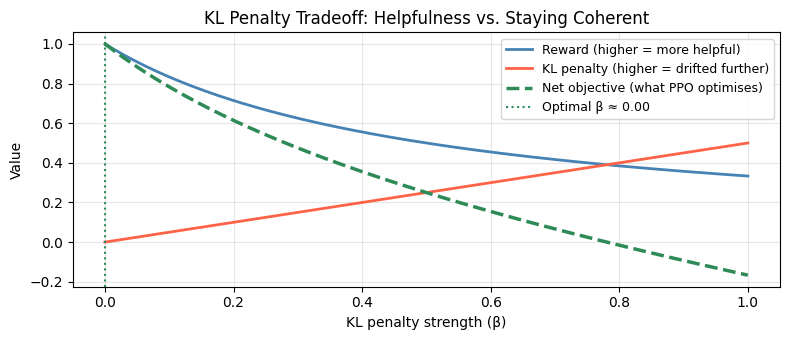

Too little β → model games the reward model (reward hacking)
Too much  β → model barely moves from SFT baseline
Goldilocks β → meaningful improvement while staying coherent


In [ ]:
# ── Visualise the KL penalty tradeoff ────────────────────────────────────────
betas   = np.linspace(0, 1, 200)
reward  = 1.0 / (1 + 2 * betas)          # reward decreases as penalty grows
kl_cost = betas                           # KL penalty grows with beta
total   = reward - kl_cost * 0.5         # net objective

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(betas, reward,  label="Reward (higher = more helpful)",  color="steelblue", lw=2)
ax.plot(betas, kl_cost*0.5, label="KL penalty (higher = drifted further)", color="tomato",    lw=2)
ax.plot(betas, total,   label="Net objective (what PPO optimises)", color="seagreen",  lw=2.5, linestyle="--")
ax.axvline(betas[np.argmax(total)], color="seagreen", linestyle=":", lw=1.5,
           label=f"Optimal β ≈ {betas[np.argmax(total)]:.2f}")
ax.set_xlabel("KL penalty strength (β)"); ax.set_ylabel("Value")
ax.set_title("KL Penalty Tradeoff: Helpfulness vs. Staying Coherent")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Too little β → model games the reward model (reward hacking)")
print("Too much  β → model barely moves from SFT baseline")
print("Goldilocks β → meaningful improvement while staying coherent")

---
## Part 3 — LoRA: Fine-tuning with Almost No Compute

### The problem

Full fine-tuning of GPT-2 Medium (355M params) requires storing and updating 355M gradients. GPT-3 has 175 **billion** parameters — full fine-tuning is simply impossible for most organisations.

### The insight (Hu et al., 2021)

Pre-trained LLMs are **over-parameterised**. During fine-tuning, the weight changes $\Delta W$ live in a **low-dimensional subspace** — most of the update can be captured with far fewer numbers.

**LoRA** (Low-Rank Adaptation) exploits this:

$$W_{\text{new}} = W_0 + \Delta W = W_0 + BA$$

Where:
- $W_0 \in \mathbb{R}^{d \times d}$ — frozen pretrained weights (never updated)
- $B \in \mathbb{R}^{d \times r}$, $A \in \mathbb{R}^{r \times d}$ — trainable low-rank matrices
- $r \ll d$ — the rank (e.g., $r=8$ vs $d=768$)

Instead of updating $d^2 = 768^2 = 589{,}824$ numbers, we only update $2 \times d \times r = 2 \times 768 \times 8 = 12{,}288$ — a **48× reduction** for a single layer.

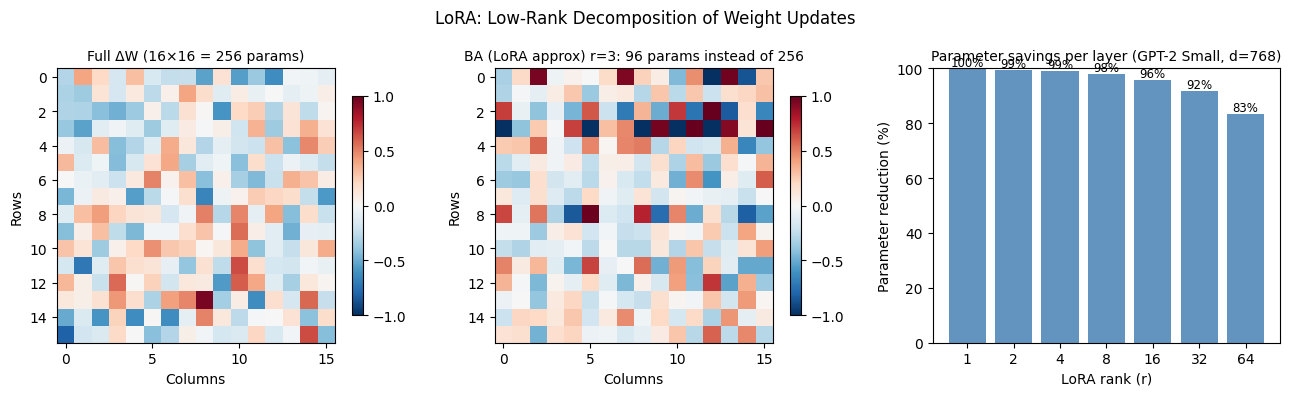

GPT-2 Small: full attention weight = 589,824 params per matrix
LoRA r=8:    12,288 params per matrix → 98% reduction

In practice, LoRA is applied to Q, K, V, and out_proj matrices in every block.
GPT-2 Small has 12 blocks × 4 matrices = 48 LoRA injections.


In [ ]:
# ── Visualise the LoRA decomposition ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("LoRA: Low-Rank Decomposition of Weight Updates", fontsize=12)

d, r = 16, 3   # small numbers for visualisation

# Full weight matrix (what full fine-tuning updates)
W_full = np.random.randn(d, d) * 0.3
im0 = axes[0].imshow(W_full, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
axes[0].set_title(f"Full ΔW ({d}×{d} = {d*d} params)", fontsize=10)
axes[0].set_xlabel("Columns"); axes[0].set_ylabel("Rows")
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Low-rank approximation
B = np.random.randn(d, r) * 0.5
A = np.random.randn(r, d) * 0.5
BA = B @ A # instead of updating W directly, approximate the update ΔW as a product of two small matrices:

im1 = axes[1].imshow(BA, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
axes[1].set_title(f"BA (LoRA approx) r={r}: {d*r + r*d} params instead of {d*d}", fontsize=10)
axes[1].set_xlabel("Columns"); axes[1].set_ylabel("Rows")
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# Parameter savings across ranks for GPT-2 Small
ranks = [1, 2, 4, 8, 16, 32, 64]
d_gpt2 = 768
full_params = d_gpt2 * d_gpt2
lora_params = [2 * d_gpt2 * r for r in ranks]
savings     = [100 * (1 - lp/full_params) for lp in lora_params]

axes[2].bar([str(r) for r in ranks], savings, color="steelblue", alpha=0.85)
axes[2].set_xlabel("LoRA rank (r)"); axes[2].set_ylabel("Parameter reduction (%)")
axes[2].set_title("Parameter savings per layer (GPT-2 Small, d=768)", fontsize=10)
axes[2].set_ylim(0, 100)
for i, (r, s) in enumerate(zip(ranks, savings)):
    axes[2].text(i, s+1, f"{s:.0f}%", ha="center", fontsize=8.5)

plt.tight_layout(); plt.show()

print(f"GPT-2 Small: full attention weight = {full_params:,} params per matrix")
print(f"LoRA r=8:    {2*d_gpt2*8:,} params per matrix → {100*(1-2*d_gpt2*8/full_params):.0f}% reduction")
print(f"\nIn practice, LoRA is applied to Q, K, V, and out_proj matrices in every block.")
print(f"GPT-2 Small has 12 blocks × 4 matrices = 48 LoRA injections.")

In [ ]:
# ── Implement a minimal LoRA layer from scratch ───────────────────────────────
import torch
import torch.nn as nn

class LoRALinear(nn.Module):
    """
    A drop-in replacement for nn.Linear that adds a low-rank adapter.
    The original weights W0 are FROZEN. Only A and B are trained.
    """
    def __init__(self, in_features, out_features, r=8, lora_alpha=16):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.r            = r
        self.scaling      = lora_alpha / r   # scaling factor (keeps magnitude stable)

        # ── Frozen pretrained weight ──────────────────────────────────────
        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.02, requires_grad=False
        )

        # ── Trainable low-rank matrices ───────────────────────────────────
        self.lora_A = nn.Parameter(torch.randn(r, in_features)  * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(out_features, r))  # init B=0 → ΔW=0 at start

    def forward(self, x):
        # Standard linear + low-rank update
        base   = nn.functional.linear(x, self.weight)
        lora   = nn.functional.linear(nn.functional.linear(x, self.lora_A), self.lora_B)
        return base + self.scaling * lora


# ── Count parameters: LoRA vs Full ───────────────────────────────────────────
d_in, d_out, rank = 768, 768, 8

full_layer = nn.Linear(d_in, d_out)
lora_layer = LoRALinear(d_in, d_out, r=rank)

full_trainable = sum(p.numel() for p in full_layer.parameters() if p.requires_grad)
lora_trainable = sum(p.numel() for p in lora_layer.parameters() if p.requires_grad)
lora_total     = sum(p.numel() for p in lora_layer.parameters())

print(f"Full fine-tuning: {full_trainable:,} trainable params")
print(f"LoRA (r={rank}):      {lora_trainable:,} trainable / {lora_total:,} total params")
print(f"Trainable reduction: {100*(1 - lora_trainable/full_trainable):.1f}%")

# ── Verify the forward pass works and shapes are correct ─────────────────────
x_test = torch.randn(4, 10, d_in)   # (batch, seq_len, d_model)
out    = lora_layer(x_test)
print(f"\nInput shape:  {x_test.shape}")
print(f"Output shape: {out.shape}   (same as full linear — drop-in replacement ✓)")
print(f"\nNote: lora_B is initialised to 0, so at step 0, ΔW = B@A = 0.")
print("This means training starts exactly from the pretrained model — no disruption.")

Full fine-tuning: 590,592 trainable params
LoRA (r=8):      12,288 trainable / 602,112 total params
Trainable reduction: 97.9%

Input shape:  torch.Size([4, 10, 768])
Output shape: torch.Size([4, 10, 768])   (same as full linear — drop-in replacement ✓)

Note: lora_B is initialised to 0, so at step 0, ΔW = B@A = 0.
This means training starts exactly from the pretrained model — no disruption.


### LoRA in the RLHF context

During PPO fine-tuning:
- The **frozen pretrained weights** $W_0$ capture general language knowledge
- The **LoRA adapters** $B, A$ capture the task-specific adjustment (be helpful, be safe, follow instructions)
- Because adapters are tiny, we can afford to keep a **reference model** in memory at the same time (needed for the KL penalty)
- After training, we can **merge** $W_0 + BA$ back into a single matrix for inference — zero overhead

---
## Part 4 — A Working RLHF Demo

### Setup

The modern recommended
approach for RLHF-style training is **GRPO** (Group Relative Policy Optimization),
which is more memory-efficient than PPO, requires no separate value-head model,
and was used to train DeepSeek-R1.

We use `GRPOTrainer` here — the concepts are identical to PPO (policy, reward,
KL penalty) but the implementation is cleaner and actively maintained.

- **Policy**: `lvwerra/gpt2-imdb` — GPT-2 fine-tuned on IMDB (our SFT model)
- **Reward function**: a DistilBERT sentiment classifier — positive logit = reward
- **Algorithm**: GRPO with KL penalty against the reference model
- **Task**: push the LLM to generate positive-sounding movie review continuations

In [ ]:
# ── Install dependencies ─────────────────────────────────────────────────────
!pip install -q transformers datasets trl peft accelerate
print("Dependencies installed ✓")

# Verify trl version
import trl
print(f"trl version: {trl.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.4 MB/s eta 0:00:00
Dependencies installed ✓
trl version: 1.6.0


In [ ]:
import torch
from tqdm import tqdm
import pandas as pd
tqdm.pandas()

from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from trl import GRPOTrainer, GRPOConfig

device = 0 if torch.cuda.is_available() else "cpu"
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

Using device: GPU


### Stage 1 (SFT) — already done

`lvwerra/gpt2-imdb` is GPT-2 fine-tuned on 25,000 IMDB reviews. It already
knows how to write movie-review-sounding text. We load it as our SFT starting
point — no retraining needed here.

In [ ]:
# ── Load the SFT model and tokenizer ─────────────────────────────────────────
model_name = "lvwerra/gpt2-imdb"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# ── Load the reward model (DistilBERT sentiment classifier) ──────────────────
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="lvwerra/distilbert-imdb",
    device=device,
    top_k=None    # returns all labels, replaces deprecated return_all_scores
)

sent_kwargs = {"return_all_scores": True, "function_to_apply": "none", "batch_size": 16}

test_texts = [
    "This movie was absolutely terrible and boring.",
    "An average film, nothing special either way.",
    "One of the best films I have ever seen in my life!"
]
print("Reward model test:")
for text in test_texts:
    outputs = sentiment_pipe(text)   # returns [{"label":..,"score":..}, ...]
    positive_score = next(d["score"] for d in outputs[0] if d["label"] == "POSITIVE")
    print(f"  Score: {positive_score:+.3f}  |  '{text[:60]}'")

print("\nHigher score → more positive sentiment → higher reward")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/17.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Reward model test:
  Score: +0.003  |  'This movie was absolutely terrible and boring.'
  Score: +0.035  |  'An average film, nothing special either way.'
  Score: +0.995  |  'One of the best films I have ever seen in my life!'

Higher score → more positive sentiment → higher reward


### Stage 2 (Reward Model) — the sentiment classifier

In real RLHF, this stage trains a reward model on human preference comparisons.
Here we use a pre-trained DistilBERT sentiment classifier as a drop-in reward.

**The reward function** we pass to GRPO takes a list of generated texts and
returns a scalar score for each — positive sentiment logit from DistilBERT.
This is all GRPO needs: any callable that maps text → scalar reward.

In [ ]:
# ── Load IMDB dataset ────────────────────────────────────────────────────────
# NOTE: newer huggingface_hub versions reject bare dataset names like "imdb".
# Repo IDs must now be in "namespace/name" form, so we use the canonical
# location of the IMDB dataset: "stanfordnlp/imdb".
dataset = load_dataset("stanfordnlp/imdb", split="train")
dataset = dataset.rename_columns({"text": "prompt"})       # GRPO expects a "prompt" column
dataset = dataset.filter(lambda x: len(x["prompt"]) > 200)  # drop very short reviews
# Keep only short prompts (first 40 chars) as generation seeds
dataset = dataset.map(lambda x: {"prompt": x["prompt"][:40]})
dataset = dataset.select(range(500))   # small subset for demo speed

print(f"Dataset size: {len(dataset)} examples")
print("\nExample prompts:")
for i in range(3):
    print(f"  '{dataset[i]['prompt']}'")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/24895 [00:00<?, ? examples/s]

Dataset size: 500 examples

Example prompts:
  'I rented I AM CURIOUS-YELLOW from my vid'
  '"I Am Curious: Yellow" is a risible and '
  'If only to avoid making this type of fil'


In [ ]:
# ── Define the reward function ───────────────────────────────────────────────
# GRPOTrainer expects reward_funcs: a callable (or list) that takes
# (prompts, completions) and returns a list of scalar rewards.

def sentiment_reward(prompts, completions, **kwargs):
    texts   = [p + c for p, c in zip(prompts, completions)]
    outputs = sentiment_pipe(texts, **sent_kwargs)
    rewards = [float(next(d["score"] for d in out if d["label"] == "POSITIVE"))
               for out in outputs]
    return rewards

# Quick test
test_prompts     = ["The movie was"]
test_completions = [" absolutely fantastic and thrilling!"]
print("Reward test:", sentiment_reward(test_prompts, test_completions))

Reward test: [2.8042469024658203]


In [ ]:
# ── GRPO config ──────────────────────────────────────────────────────────────
# GRPO key hyperparameters:
#   num_generations  — how many completions to sample per prompt (like a mini-batch within a step)
#    max_completion_length   — length of each generated completion
#   beta         — strength of KL penalty keeping model close to SFT baseline

config = GRPOConfig(
    output_dir="grpo_imdb",
    num_generations=4,
    max_completion_length=20,
    learning_rate=1.41e-5,
    per_device_train_batch_size=4,
    num_train_epochs=1,
    max_steps=100,
    logging_steps=5,
    beta=0.05,
    report_to="none",
)

print("GRPO config ready.")

GRPO config ready.


In [ ]:
# ── Initialise the GRPO trainer ──────────────────────────────────────────────
trainer = GRPOTrainer(
    model=model_name,
    args=config,                 # replaces positional config
    reward_funcs=sentiment_reward,
    train_dataset=dataset,
    processing_class=tokenizer,
)

print("GRPOTrainer ready ✓")
print("\nHow GRPO differs from PPO:")
print("  PPO:  needs a separate value-head model to estimate V(s) → 2x memory")
print("  GRPO: estimates advantage by comparing rewards within a group of")
print("        completions → no value model needed, simpler and faster")

pytorch_model.bin:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

GRPOTrainer ready ✓

How GRPO differs from PPO:
  PPO:  needs a separate value-head model to estimate V(s) → 2x memory
  GRPO: estimates advantage by comparing rewards within a group of
        completions → no value model needed, simpler and faster


### Stage 3 — The GRPO Training Loop

Each step:
1. Sample a batch of prompts from the dataset
2. Generate `num_generations=4` completions per prompt using the **current policy**
3. Score each completion with our **reward function** (sentiment classifier)
4. Compute group-relative advantage: completions scoring above the group mean get positive advantage
5. PPO-style gradient update + KL penalty against the reference model

The group-relative advantage is the key insight: instead of needing a learned value function to estimate "how good is this state?", GRPO uses the **relative ranking within the batch** as a natural baseline.

In [ ]:
# ── Run GRPO training ────────────────────────────────────────────────────────
print("Starting GRPO training (30 steps)...")
print("=" * 55)

trainer.train()

print("=" * 55)
print("Training complete!")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


Starting GRPO training (30 steps)...


Step,Training Loss
5,0.000268
10,0.024964
15,-0.019146
20,0.001892
25,0.005856
30,0.012118
35,-0.020919
40,0.002177
45,0.010268
50,0.022449


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete!


### Evaluation: Before vs After

We compare the **reference model** (frozen SFT baseline) against the **fine-tuned policy** on the same prompts. A successful RLHF run will show higher sentiment scores in the tuned model.

In [ ]:
# ── Compare before / after on the same prompts ──────────────────────────────
import random
random.seed(42)

sample_prompts = [dataset[i]["prompt"] for i in range(16)]

# Reference: generate with the original SFT model (untrained)
ref_model_hf = AutoModelForCausalLM.from_pretrained(model_name)
ref_model_hf.eval()

def generate_completions(model_or_name, prompts, max_new_tokens=20):
    if isinstance(model_or_name, str):
        m = AutoModelForCausalLM.from_pretrained(model_or_name)
    else:
        m = model_or_name
    m.eval()
    device = next(m.parameters()).device   # ← detect model's device automatically
    completions = []
    for prompt in prompts:
        inputs = tokenizer(prompt, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}   # ← move to device
        with torch.no_grad():
            out = m.generate(**inputs, max_new_tokens=max_new_tokens,
                             do_sample=True, top_p=1.0, top_k=0,
                             pad_token_id=tokenizer.eos_token_id)
        completion = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:],
                                       skip_special_tokens=True)
        completions.append(completion)
    return completions

print("Generating responses from reference model (before GRPO)...")
completions_before = generate_completions(ref_model_hf, sample_prompts)

print("Generating responses from trained model (after GRPO)...")
completions_after = generate_completions(trainer.model, sample_prompts)

# Score both
rewards_before = sentiment_reward(sample_prompts, completions_before)
rewards_after  = sentiment_reward(sample_prompts, completions_after)

df_results = pd.DataFrame({
    "prompt":           sample_prompts,
    "response (before)": completions_before,
    "reward (before)":   rewards_before,
    "response (after)":  completions_after,
    "reward (after)":    rewards_after,
})

print(df_results[["prompt","response (before)","reward (before)",
                   "response (after)","reward (after)"]].head(5).to_string(index=False))

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

Generating responses from reference model (before GRPO)...
Generating responses from trained model (after GRPO)...
                                  prompt                                                                               response (before)  reward (before)                                                                                       response (after)  reward (after)
I rented I AM CURIOUS-YELLOW from my vid                                ata. That must be one acting studio wanker...<br /><br />Shellsh        -2.085180                                                                     ya collection). Se comment scored!        0.104963
"I Am Curious: Yellow" is a risible and  ersatz cinematic trash has the mentality  that of expressing or reproducing a type of horror �        -2.437540  icky take on "A Beautiful Mind" beautifully executed in a way that requires no philosophy or depth to        1.520828
If only to avoid making this type of fil                    th3 ea

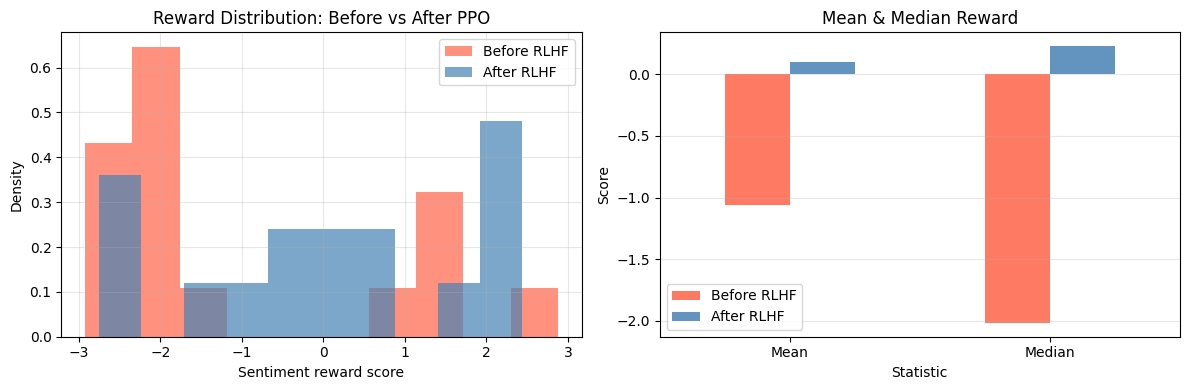

Summary statistics:
        reward (before)  reward (after)
mean            -1.0617          0.1012
median          -2.0170          0.2281

Even 3 PPO steps should shift the mean reward upward.
With 100+ steps, the gap becomes much more pronounced.


In [ ]:
# ── Plot reward distributions: before vs after ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution plot
axes[0].hist(df_results["reward (before)"], bins=10, alpha=0.7,
             color="tomato", label="Before RLHF", density=True)
axes[0].hist(df_results["reward (after)"],  bins=10, alpha=0.7,
             color="steelblue", label="After RLHF",  density=True)
axes[0].set_xlabel("Sentiment reward score")
axes[0].set_ylabel("Density")
axes[0].set_title("Reward Distribution: Before vs After PPO")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Mean/median comparison
stats_df = df_results[["reward (before)", "reward (after)"]].agg(["mean","median"])
stats_df.plot(kind="bar", ax=axes[1], color=["tomato","steelblue"], alpha=0.85)
axes[1].set_title("Mean & Median Reward")
axes[1].set_xlabel("Statistic"); axes[1].set_ylabel("Score")
axes[1].set_xticklabels(["Mean", "Median"], rotation=0)
axes[1].legend(["Before RLHF", "After RLHF"])
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

print("Summary statistics:")
print(stats_df.round(4))
print("\nEven 3 PPO steps should shift the mean reward upward.")
print("With 100+ steps, the gap becomes much more pronounced.")

### What just happened?

In 3 PPO batches the model has already learned to nudge its continuations toward more positive-sounding language. With 100+ steps (and a real human preference dataset instead of a sentiment classifier), this is how ChatGPT, Claude, and Gemini are trained to be helpful, harmless, and honest.

The three stages together:

| Stage | What it learns | Data needed |
|---|---|---|
| SFT | How to follow instructions at all | ~10k human-written examples |
| Reward Model | What humans consider a good response | ~100k human preference comparisons |
| PPO | How to optimise for that reward without breaking | Reward model + KL anchor |

LoRA makes stages 2 and 3 feasible on a single GPU by keeping 95–99% of parameters frozen.